In [1]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

print(df.shape)
print(df.head())
print(df.info())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [2]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum().sum())  # should be 0

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Class distribution
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Missing values per column:
0
Duplicate rows: 1081
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


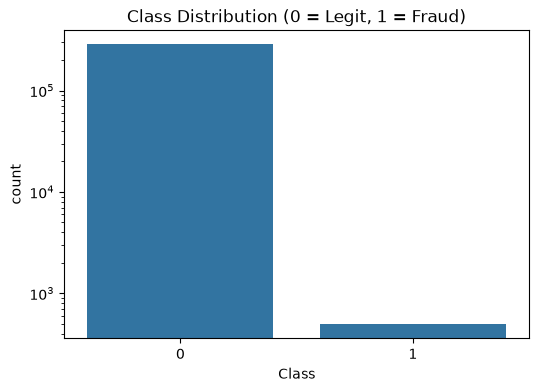

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.yscale('log')  # log scale so the tiny fraud bar is actually visible
plt.show()

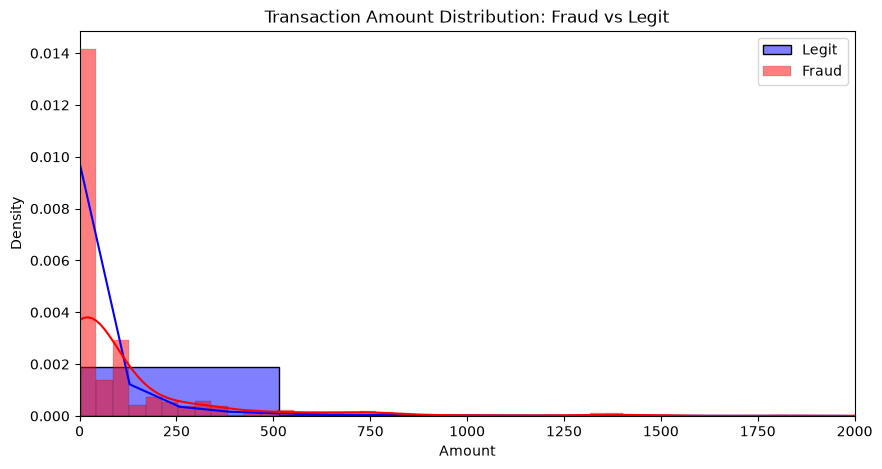

In [4]:
# Plot 2: Amount distribution, fraud vs legit
plt.figure(figsize=(10,5))
sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='blue', label='Legit', stat='density', kde=True)
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='red', label='Fraud', stat='density', kde=True)
plt.legend()
plt.title('Transaction Amount Distribution: Fraud vs Legit')
plt.xlim(0, 2000)  # zoom in, since most transactions are small amounts
plt.show()

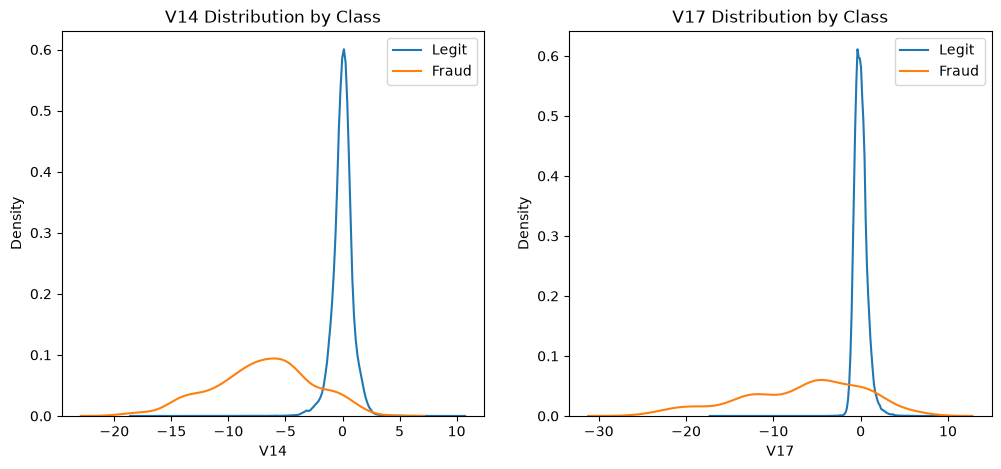

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.kdeplot(df[df['Class']==0]['V14'], label='Legit', ax=axes[0])
sns.kdeplot(df[df['Class']==1]['V14'], label='Fraud', ax=axes[0])
axes[0].set_title('V14 Distribution by Class')
axes[0].legend()

sns.kdeplot(df[df['Class']==0]['V17'], label='Legit', ax=axes[1])
sns.kdeplot(df[df['Class']==1]['V17'], label='Fraud', ax=axes[1])
axes[1].set_title('V17 Distribution by Class')
axes[1].legend()

plt.show()

In [6]:
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Before removing duplicates: (284807, 31)
After removing duplicates: (283726, 31)


In [7]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

df = df.drop(['Amount', 'Time'], axis=1)

print(df.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  Amount_scaled  Time_scaled  

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Fraud ratio in train:", y_train.mean())
print("Fraud ratio in test:", y_test.mean())

Training set shape: (226980, 30)
Test set shape: (56746, 30)
Fraud ratio in train: 0.0016653449643140364
Fraud ratio in test: 0.0016741268107003137


In [9]:
# Check the class imbalance ratio, needed for weighting
fraud_ratio = y_train.value_counts()
print(fraud_ratio)

# Class weighting - sklearn can compute this automatically
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
print("Computed class weights:", class_weights)

Class
0    226602
1       378
Name: count, dtype: int64
Computed class weights: [  0.50083406 300.23809524]


In [10]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = log_reg.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[55262  1389]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Class
0    226602
1       378
Name: count, dtype: int64
After SMOTE: Class
0    226602
1    226602
Name: count, dtype: int64


In [13]:
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = log_reg_smote.predict(X_test)

print("Confusion Matrix (SMOTE):")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report (SMOTE):")
print(classification_report(y_test, y_pred_smote))

Confusion Matrix (SMOTE):
[[55194  1457]
 [   12    83]]

Classification Report (SMOTE):
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Confusion Matrix (Random Forest, class weights):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report (Random Forest, class weights):")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix (Random Forest, class weights):
[[56648     3]
 [   26    69]]

Classification Report (Random Forest, class weights):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [15]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)

print("Confusion Matrix (Random Forest, SMOTE):")
print(confusion_matrix(y_test, y_pred_rf_smote))

print("\nClassification Report (Random Forest, SMOTE):")
print(classification_report(y_test, y_pred_rf_smote))

Confusion Matrix (Random Forest, SMOTE):
[[56644     7]
 [   22    73]]

Classification Report (Random Forest, SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [16]:
from xgboost import XGBClassifier

# Calculate the ratio for scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Confusion Matrix (XGBoost, class weights):")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report (XGBoost, class weights):")
print(classification_report(y_test, y_pred_xgb))

scale_pos_weight: 599.4761904761905
Confusion Matrix (XGBoost, class weights):
[[56648     3]
 [   21    74]]

Classification Report (XGBoost, class weights):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.78      0.86        95

    accuracy                           1.00     56746
   macro avg       0.98      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [17]:
xgb_smote = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)

print("Confusion Matrix (XGBoost, SMOTE):")
print(confusion_matrix(y_test, y_pred_xgb_smote))

print("\nClassification Report (XGBoost, SMOTE):")
print(classification_report(y_test, y_pred_xgb_smote))

Confusion Matrix (XGBoost, SMOTE):
[[56624    27]
 [   21    74]]

Classification Report (XGBoost, SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.73      0.78      0.76        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



In [18]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_tune = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best F1 score (cross-validated):", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best F1 score (cross-validated): 0.8593268825957784


In [19]:
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print("Confusion Matrix (Tuned XGBoost):")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred_best))

Confusion Matrix (Tuned XGBoost):
[[56646     5]
 [   22    73]]

Classification Report (Tuned XGBoost):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.77      0.84        95

    accuracy                           1.00     56746
   macro avg       0.97      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [20]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Get probability of fraud (class 1) for each test transaction
y_probs = xgb.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    results.append([t, precision, recall, f1])

results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])
print(results_df)

    Threshold  Precision    Recall        F1
0        0.10   0.844444  0.800000  0.821622
1        0.15   0.863636  0.800000  0.830601
2        0.20   0.915663  0.800000  0.853933
3        0.25   0.915663  0.800000  0.853933
4        0.30   0.925926  0.789474  0.852273
5        0.35   0.925926  0.789474  0.852273
6        0.40   0.925926  0.789474  0.852273
7        0.45   0.949367  0.789474  0.862069
8        0.50   0.961039  0.778947  0.860465
9        0.55   0.961039  0.778947  0.860465
10       0.60   0.961039  0.778947  0.860465
11       0.65   0.973684  0.778947  0.865497
12       0.70   0.973333  0.768421  0.858824
13       0.75   0.986486  0.768421  0.863905
14       0.80   0.986486  0.768421  0.863905
15       0.85   0.986486  0.768421  0.863905
16       0.90   0.986111  0.747368  0.850299


In [21]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf),
        ('lr', log_reg)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

y_pred_ensemble = ensemble.predict(X_test)

print("Confusion Matrix (Ensemble):")
print(confusion_matrix(y_test, y_pred_ensemble))

print("\nClassification Report (Ensemble):")
print(classification_report(y_test, y_pred_ensemble))

Confusion Matrix (Ensemble):
[[56642     9]
 [   20    75]]

Classification Report (Ensemble):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.79      0.84        95

    accuracy                           1.00     56746
   macro avg       0.95      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [22]:
ensemble_strong = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf)
    ],
    voting='soft'
)

ensemble_strong.fit(X_train, y_train)

y_pred_ensemble_strong = ensemble_strong.predict(X_test)

print("Confusion Matrix (Ensemble: XGB + RF only):")
print(confusion_matrix(y_test, y_pred_ensemble_strong))

print("\nClassification Report (Ensemble: XGB + RF only):")
print(classification_report(y_test, y_pred_ensemble_strong))

Confusion Matrix (Ensemble: XGB + RF only):
[[56650     1]
 [   21    74]]

Classification Report (Ensemble: XGB + RF only):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.99      0.78      0.87        95

    accuracy                           1.00     56746
   macro avg       0.99      0.89      0.94     56746
weighted avg       1.00      1.00      1.00     56746



In [23]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=200, contamination=0.0017, random_state=42, n_jobs=-1)
iso.fit(X_train)

# decision_function gives anomaly score (lower = more anomalous)
X_train_iso = X_train.copy()
X_train_iso['anomaly_score'] = iso.decision_function(X_train)

X_test_iso = X_test.copy()
X_test_iso['anomaly_score'] = iso.decision_function(X_test)

In [24]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

lgbm = LGBMClassifier(scale_pos_weight=scale_pos_weight, n_estimators=200, random_state=42)
lgbm.fit(X_train_iso, y_train)

catboost = CatBoostClassifier(
    class_weights=[1, scale_pos_weight],
    iterations=200,
    random_state=42,
    verbose=0
)
catboost.fit(X_train_iso, y_train)

[LightGBM] [Info] Number of positive: 378, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041182 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7905
[LightGBM] [Info] Number of data points in the train set: 226980, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001665 -> initscore=-6.396056
[LightGBM] [Info] Start training from score -6.396056
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

CatBoostClassifier(class_weights=[1, np.float64(599.4761904761905)], iterations=200, random_state=42, verbose=0)

In [25]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

stack = StackingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf),
        ('lgbm', lgbm)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stack.fit(X_train_iso, y_train)

y_pred_stack = stack.predict(X_test_iso)

print("Confusion Matrix (Stacked Ensemble):")
print(confusion_matrix(y_test, y_pred_stack))

print("\nClassification Report (Stacked Ensemble):")
print(classification_report(y_test, y_pred_stack))

Confusion Matrix (Stacked Ensemble):
[[56650     1]
 [   25    70]]

Classification Report (Stacked Ensemble):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.99      0.74      0.84        95

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [26]:
# If you still have the original unscaled df, use it. 
# Otherwise reload and rebuild hour_of_day from a fresh copy.
df_raw = pd.read_csv("../data/creditcard.csv")

df_raw['hour_of_day'] = (df_raw['Time'] // 3600) % 24

# Fraud rate per hour
fraud_by_hour = df_raw.groupby('hour_of_day')['Class'].mean() * 100
transaction_count_by_hour = df_raw.groupby('hour_of_day')['Class'].count()

print(fraud_by_hour)

hour_of_day
0.0     0.077973
1.0     0.236967
2.0     1.712740
3.0     0.486827
4.0     1.041195
5.0     0.367893
6.0     0.219459
7.0     0.317548
8.0     0.087583
9.0     0.101023
10.0    0.048199
11.0    0.314428
12.0    0.110246
13.0    0.110641
14.0    0.138805
15.0    0.157949
16.0    0.133714
17.0    0.179389
18.0    0.193673
19.0    0.121414
20.0    0.107424
21.0    0.090380
22.0    0.058286
23.0    0.191991
Name: Class, dtype: float64


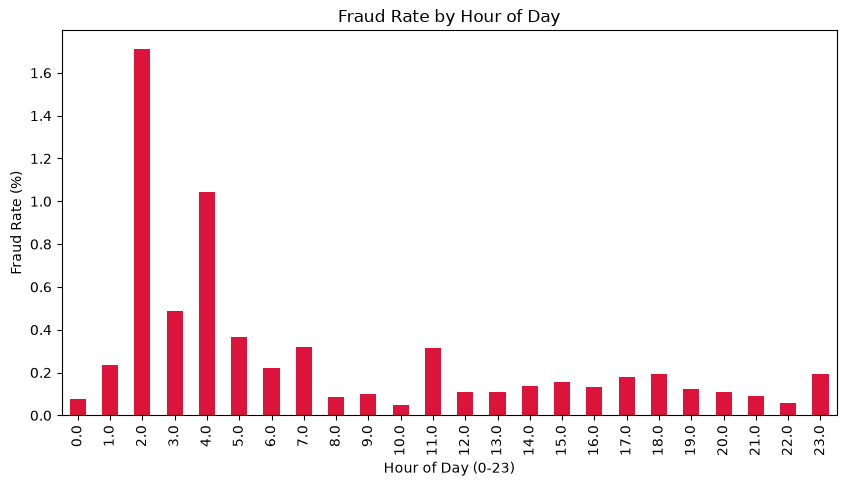

In [27]:
plt.figure(figsize=(10,5))
fraud_by_hour.plot(kind='bar', color='crimson')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.show()

In [28]:
# Recreate hour_of_day from the raw, unscaled Time column
df_raw['hour_of_day'] = (df_raw['Time'] // 3600) % 24

# Match it back to your train/test sets using their original row index
X_train_hour = X_train.copy()
X_test_hour = X_test.copy()

X_train_hour['hour_of_day'] = df_raw.loc[X_train_hour.index, 'hour_of_day']
X_test_hour['hour_of_day'] = df_raw.loc[X_test_hour.index, 'hour_of_day']

print(X_train_hour[['hour_of_day']].head())

        hour_of_day
226238         16.0
134253         22.0
186465         11.0
149493          1.0
18461           8.0


In [29]:
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

xgb_hour = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
xgb_hour.fit(X_train_hour, y_train)

y_pred_hour = xgb_hour.predict(X_test_hour)

print("Confusion Matrix (XGBoost + hour_of_day feature):")
print(confusion_matrix(y_test, y_pred_hour))
print("\nClassification Report (XGBoost + hour_of_day feature):")
print(classification_report(y_test, y_pred_hour))

Confusion Matrix (XGBoost + hour_of_day feature):
[[56645     6]
 [   22    73]]

Classification Report (XGBoost + hour_of_day feature):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.77      0.84        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [30]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Use your best model - the XGB+RF ensemble
y_probs_ensemble = ensemble_strong.predict_proba(X_test)[:, 1]

thresholds_fine = np.arange(0.01, 0.55, 0.02)
results_fine = []

for t in thresholds_fine:
    y_pred_t = (y_probs_ensemble >= t).astype(int)
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    results_fine.append([t, precision, recall, f1])

results_fine_df = pd.DataFrame(results_fine, columns=['Threshold', 'Precision', 'Recall', 'F1'])
print(results_fine_df)

    Threshold  Precision    Recall        F1
0        0.01   0.118519  0.842105  0.207792
1        0.03   0.472727  0.821053  0.600000
2        0.05   0.644628  0.821053  0.722222
3        0.07   0.722222  0.821053  0.768473
4        0.09   0.754902  0.810526  0.781726
5        0.11   0.802083  0.810526  0.806283
6        0.13   0.836957  0.810526  0.823529
7        0.15   0.846154  0.810526  0.827957
8        0.17   0.863636  0.800000  0.830601
9        0.19   0.863636  0.800000  0.830601
10       0.21   0.883721  0.800000  0.839779
11       0.23   0.894118  0.800000  0.844444
12       0.25   0.892857  0.789474  0.837989
13       0.27   0.903614  0.789474  0.842697
14       0.29   0.903614  0.789474  0.842697
15       0.31   0.903614  0.789474  0.842697
16       0.33   0.925926  0.789474  0.852273
17       0.35   0.949367  0.789474  0.862069
18       0.37   0.949367  0.789474  0.862069
19       0.39   0.948718  0.778947  0.855491
20       0.41   0.948718  0.778947  0.855491
21       0

In [31]:
from sklearn.metrics import roc_auc_score, average_precision_score

# y_probs_ensemble already exists from your threshold optimization step
roc_auc = roc_auc_score(y_test, y_probs_ensemble)
pr_auc = average_precision_score(y_test, y_probs_ensemble)

print("ROC-AUC (Ensemble):", roc_auc)
print("PR-AUC (Ensemble):", pr_auc)

ROC-AUC (Ensemble): 0.9714874731620847
PR-AUC (Ensemble): 0.8135422420334084


In [32]:
y_probs_xgb = xgb.predict_proba(X_test)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_probs_xgb)
pr_auc_xgb = average_precision_score(y_test, y_probs_xgb)

print("ROC-AUC (XGBoost):", roc_auc_xgb)
print("PR-AUC (XGBoost):", pr_auc_xgb)

ROC-AUC (XGBoost): 0.9727712336568592
PR-AUC (XGBoost): 0.8251705188355395
